# T6 — Desarrollo del Motor de Similitud (Matching) y Cálculo de Ranks

**Tesis:** "Diseño e Implementación de un Sistema de Recomendación Laboral  
para Optimizar el Matching entre Candidatos y Ofertas de Empleo"  
**Alumno:** Cicconi, Carlos Alberto  
**Maestría:** Explotación de Datos y Gestión del Conocimiento — Universidad Austral  
**Período:** 01/02/2026 – 15/02/2026

---

## Objetivos de esta etapa

| # | Objetivo |
|---|----------|
| 1 | Integrar los rankings de TF-IDF (T4) y Sentence-BERT (T5) en un único motor |
| 2 | Implementar el **score híbrido ponderado** como función de ranking final |
| 3 | Calcular métricas de evaluación: **Precision@K**, **nDCG@K** y **MRR** |
| 4 | Analizar la calidad del matching por keyword, fuente y modalidad |
| 5 | Producir casos de estudio cualitativos del Top-10 |
| 6 | Generar el **reporte ejecutivo** del motor de matching |

### Inputs
- `ofertas_preprocesadas.csv` — corpus con `similitud_tfidf` y (si existe) `similitud_embed`
- `embeddings_ranking.csv` — ranking SBERT con `similitud_embed` (salida T5)
- `tfidf_ranking_baseline.csv` — ranking TF-IDF con `rank_tfidf` (salida T4)
- `modelo_embeddings_info.json` — metadatos del modelo (salida T5)

### Outputs
- `ranking_final_combinado.csv` — ranking híbrido con score ponderado
- `metricas_evaluacion.json` — Precision@K, nDCG@K, MRR para TF-IDF, SBERT e híbrido
- `reporte_matching.md` — reporte legible con Top-20 y análisis para la tesis


## 0. Configuración del entorno

In [1]:
import json
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})

print('✅ Entorno configurado')
print(f'   pandas {pd.__version__}  |  numpy {np.__version__}')

# ── Rutas del proyecto (resueltas desde la ubicación del notebook) ────────────
from pathlib import Path
_NB   = Path(globals().get('__vsc_ipynb_file__', Path.cwd())).resolve()
_ROOT = _NB.parent if _NB.name != 'notebooks' else _NB.parent
if _ROOT.name == 'notebooks': _ROOT = _ROOT.parent
_PROC    = _ROOT / 'data'    / 'processed'
_RANKINGS= _ROOT / 'outputs' / 'rankings'
_REPORTS = _ROOT / 'outputs' / 'reports'
_FIGS    = _ROOT / 'outputs' / 'figures'
_PROC.mkdir(parents=True, exist_ok=True)
_RANKINGS.mkdir(parents=True, exist_ok=True)
_REPORTS.mkdir(parents=True, exist_ok=True)
_FIGS.mkdir(parents=True, exist_ok=True)
print(f'ROOT     : {_ROOT}')
print(f'PROC     : {_PROC}')
print(f'RANKINGS : {_RANKINGS}')
print(f'REPORTS  : {_REPORTS}')
print(f'FIGS     : {_FIGS}')


✅ Entorno configurado
   pandas 2.2.3  |  numpy 2.2.4


## 1. Carga e integración de artefactos

In [2]:
# ── Cargar corpus base ───────────────────────────────────────────────────────
# ofertas_preprocesadas.csv es la fuente de verdad: tiene todos los metadatos
# y puede incluir ya similitud_tfidf y/o similitud_embed de T4/T5.

if (_PROC / 'ofertas_preprocesadas.csv').exists():
    df = pd.read_csv(_PROC / 'ofertas_preprocesadas.csv', low_memory=False)
    print(f'✅ ofertas_preprocesadas.csv — {len(df):,} filas x {df.shape[1]} cols')
elif (_PROC / 'ofertas_con_descripcion.csv').exists():
    df = pd.read_csv(_PROC / 'ofertas_con_descripcion.csv', low_memory=False)
    print(f'✅ ofertas_con_descripcion.csv — {len(df):,} filas (fallback T3)')
else:
    raise FileNotFoundError(f'No se encontró el corpus en {_PROC}. Ejecutar T3 o T4 primero.')

print(f'   Columnas: {df.columns.tolist()}')
print()
print('Similitudes disponibles en el DataFrame:')
for col in ['similitud_tfidf', 'similitud_embed']:
    if col in df.columns:
        n = df[col].notna().sum()
        print(f'  ✅ {col:<22} — {n:,} valores ({n/len(df)*100:.0f}%)')
    else:
        print(f'  ❌ {col:<22} — no disponible')


✅ ofertas_preprocesadas.csv — 1,279 filas x 18 cols
   Columnas: ['id_consolidado', 'job_id', 'fuente', 'titulo', 'empresa', 'ubicacion', 'descripcion', 'fecha_pub_dt', 'url', 'keyword', 'nivel', 'tipo_empleo', 'modalidad', 'salario', 'fecha_scrap', 'idioma', 'texto_procesado', 'similitud_tfidf']

Similitudes disponibles en el DataFrame:
  ✅ similitud_tfidf        — 1,279 valores (100%)
  ❌ similitud_embed        — no disponible


In [3]:
# ── Cargar ranking SBERT (T5) ─────────────────────────────────────────────────
embed_rank_disp = False
if (_RANKINGS / 'embeddings_ranking.csv').exists():
    df_emb_rank = pd.read_csv(_RANKINGS / 'embeddings_ranking.csv')
    embed_rank_disp = True
    print(f'✅ embeddings_ranking.csv — {len(df_emb_rank):,} filas')
    print(f'   Columnas: {df_emb_rank.columns.tolist()}')

    # Si similitud_embed no está en df, incorporarla desde embeddings_ranking
    if 'similitud_embed' not in df.columns and 'id_consolidado' in df_emb_rank.columns:
        df = df.merge(
            df_emb_rank[['id_consolidado', 'similitud_embed']],
            on='id_consolidado', how='left'
        )
        print('   ℹ️  similitud_embed incorporada al DataFrame desde embeddings_ranking.csv')
else:
    df_emb_rank = None
    print('ℹ️  embeddings_ranking.csv no encontrado — ejecutar T5 para generarlo')

# ── Cargar ranking TF-IDF (T4) ───────────────────────────────────────────────
tfidf_rank_disp = False
if (_RANKINGS / 'tfidf_ranking_baseline.csv').exists():
    df_tfidf_rank = pd.read_csv(_RANKINGS / 'tfidf_ranking_baseline.csv')
    tfidf_rank_disp = True
    print(f'✅ tfidf_ranking_baseline.csv — {len(df_tfidf_rank):,} filas')

    if 'similitud_tfidf' not in df.columns and 'id_consolidado' in df_tfidf_rank.columns:
        df = df.merge(
            df_tfidf_rank[['id_consolidado', 'similitud_tfidf']],
            on='id_consolidado', how='left'
        )
        print('   ℹ️  similitud_tfidf incorporada al DataFrame desde tfidf_ranking_baseline.csv')
else:
    df_tfidf_rank = None
    print('ℹ️  tfidf_ranking_baseline.csv no encontrado')


✅ embeddings_ranking.csv — 1,279 filas
   Columnas: ['rank_embed', 'id_consolidado', 'fuente', 'titulo', 'empresa', 'keyword', 'ubicacion', 'modalidad', 'url', 'similitud_embed']
   ℹ️  similitud_embed incorporada al DataFrame desde embeddings_ranking.csv
✅ tfidf_ranking_baseline.csv — 1,279 filas


In [4]:
# ── Cargar metadatos del modelo ───────────────────────────────────────────────
if (_REPORTS / 'modelo_embeddings_info.json').exists():
    with open(_REPORTS / 'modelo_embeddings_info.json') as f:
        modelo_info = json.load(f)
    print('✅ modelo_embeddings_info.json')
    for k, v in modelo_info.items():
        print(f'   {k}: {v}')
else:
    modelo_info = {'modelo': 'paraphrase-multilingual-MiniLM-L12-v2',
                   'dimensiones': 384}
    print('ℹ️  modelo_embeddings_info.json no encontrado — usando valores por defecto')

# ── Estado general del corpus ─────────────────────────────────────────────────
print()
tiene_tfidf = 'similitud_tfidf' in df.columns and df['similitud_tfidf'].notna().any()
tiene_embed = 'similitud_embed' in df.columns and df['similitud_embed'].notna().any()
print(f'Estado — TF-IDF: {"✅" if tiene_tfidf else "❌"}  |  Embeddings: {"✅" if tiene_embed else "❌"}')
print(f'Modo motor: {"HÍBRIDO (TF-IDF + SBERT)" if tiene_tfidf and tiene_embed else "SBERT solo" if tiene_embed else "TF-IDF solo"}')


✅ modelo_embeddings_info.json
   modelo: paraphrase-multilingual-MiniLM-L12-v2
   dimensiones: 384
   max_chunk_chars: 800
   chunk_overlap: 100
   batch_size: 32
   n_ofertas: 1279
   fecha_encoding: 2026-04-23T20:40:52.943120
   col_texto_fuente: texto_procesado

Estado — TF-IDF: ✅  |  Embeddings: ✅
Modo motor: HÍBRIDO (TF-IDF + SBERT)


## 2. Motor de Matching: score híbrido ponderado

### Función de scoring

El motor combina ambas similitudes mediante una **combinación lineal ponderada**:

$$\text{score}_{\text{híbrido}} = w_{\text{embed}} \cdot \text{sim}_{\text{SBERT}} + w_{\text{tfidf}} \cdot \text{sim}_{\text{TF-IDF}}$$

La ponderación refleja la superioridad semántica de SBERT sobre TF-IDF,  
documentada en T5. SBERT recibe mayor peso porque:

- Captura sinónimos y relaciones semánticas que TF-IDF ignora
- Es invariante al idioma (ES/EN) dentro del mismo espacio vectorial
- Mostró menor correlación con TF-IDF → aporta información complementaria

| Configuración | $w_{\text{embed}}$ | $w_{\text{tfidf}}$ | Descripción |
|---|---|---|---|
| Solo SBERT | 1.0 | 0.0 | Máxima semántica |
| **Híbrido recomendado** | **0.7** | **0.3** | **Balance semántica + keywords** |
| Equilibrado | 0.5 | 0.5 | Peso igual |
| Solo TF-IDF | 0.0 | 1.0 | Baseline (benchmark) |

Se evalúan las cuatro configuraciones para justificar la elección en la tesis.


In [5]:
# ── Normalización Min-Max de similitudes ─────────────────────────────────────
# Necesaria para que ambas similitudes estén en la misma escala [0, 1]
# antes de combinarlas. SBERT ya está normalizado; TF-IDF puede tener
# escala diferente según el corpus.

def normalizar_minmax(serie: pd.Series) -> pd.Series:
    mn, mx = serie.min(), serie.max()
    if mx == mn:
        return serie * 0.0
    return (serie - mn) / (mx - mn)

df_motor = df.copy()

if tiene_tfidf:
    df_motor['sim_tfidf_norm'] = normalizar_minmax(df_motor['similitud_tfidf'].fillna(0))
    print(f'TF-IDF normalizado — rango: [{df_motor["sim_tfidf_norm"].min():.4f}, {df_motor["sim_tfidf_norm"].max():.4f}]')

if tiene_embed:
    df_motor['sim_embed_norm'] = normalizar_minmax(df_motor['similitud_embed'].fillna(0))
    print(f'SBERT normalizado  — rango: [{df_motor["sim_embed_norm"].min():.4f}, {df_motor["sim_embed_norm"].max():.4f}]')


TF-IDF normalizado — rango: [0.0000, 1.0000]
SBERT normalizado  — rango: [0.0000, 1.0000]


In [6]:
# ── Calcular score híbrido ────────────────────────────────────────────────────
CONFIGS = {
    'Solo SBERT':          (1.0, 0.0),
    'Híbrido 70/30':       (0.7, 0.3),
    'Híbrido 50/50':       (0.5, 0.5),
    'Solo TF-IDF':         (0.0, 1.0),
}

for nombre, (w_emb, w_tfi) in CONFIGS.items():
    if tiene_embed and tiene_tfidf:
        df_motor[f'score_{nombre}'] = (
            w_emb * df_motor.get('sim_embed_norm', pd.Series(0, index=df_motor.index)) +
            w_tfi * df_motor.get('sim_tfidf_norm', pd.Series(0, index=df_motor.index))
        )
    elif tiene_embed:
        df_motor[f'score_{nombre}'] = df_motor.get('sim_embed_norm',
                                       pd.Series(0, index=df_motor.index))
    else:
        df_motor[f'score_{nombre}'] = df_motor.get('sim_tfidf_norm',
                                       pd.Series(0, index=df_motor.index))

# Configuración principal del motor
CONFIG_PRINCIPAL = 'Híbrido 70/30' if (tiene_embed and tiene_tfidf) else \
                   'Solo SBERT'    if tiene_embed else 'Solo TF-IDF'
df_motor['score_final'] = df_motor[f'score_{CONFIG_PRINCIPAL}']

print(f'Configuración activa: {CONFIG_PRINCIPAL}')
print(f'Score final — media: {df_motor["score_final"].mean():.4f}  |  máx: {df_motor["score_final"].max():.4f}')


Configuración activa: Híbrido 70/30
Score final — media: 0.3426  |  máx: 0.8337


## 3. Ranking final y análisis de estabilidad

In [7]:
# ── Ranking final ─────────────────────────────────────────────────────────────
df_ranking = (df_motor
              .sort_values('score_final', ascending=False)
              .reset_index(drop=True))
df_ranking['rank_final'] = df_ranking.index + 1

# Agregar rank individual de cada modelo para comparación
if tiene_tfidf:
    rank_tfidf_map = (df_motor
                      .sort_values('sim_tfidf_norm', ascending=False)
                      .reset_index(drop=True)
                      .assign(rank_tfidf=lambda x: x.index + 1)
                      .set_index('id_consolidado')['rank_tfidf'])
    df_ranking['rank_tfidf'] = df_ranking['id_consolidado'].map(rank_tfidf_map)

if tiene_embed:
    rank_embed_map = (df_motor
                      .sort_values('sim_embed_norm', ascending=False)
                      .reset_index(drop=True)
                      .assign(rank_embed=lambda x: x.index + 1)
                      .set_index('id_consolidado')['rank_embed'])
    df_ranking['rank_embed'] = df_ranking['id_consolidado'].map(rank_embed_map)

print('=== TOP 20 — Ranking Final del Motor de Matching ===')
cols_show = ['rank_final', 'score_final', 'titulo', 'empresa', 'keyword',
             'fuente', 'modalidad']
if 'rank_tfidf' in df_ranking.columns:
    cols_show += ['rank_tfidf']
if 'rank_embed' in df_ranking.columns:
    cols_show += ['rank_embed']
cols_show = [c for c in cols_show if c in df_ranking.columns]

top20 = df_ranking[cols_show].head(20).copy()
top20['score_final'] = top20['score_final'].round(4)
top20


=== TOP 20 — Ranking Final del Motor de Matching ===


,rank_final,score_final,titulo,empresa,keyword,fuente,modalidad,rank_tfidf,rank_embed
0,1,0.8337,Analista Sr de Control de Gestión (Buenos Aires),Vanguardia Consultores RR.HH,Control de Gestión,opcionempleo,NaN,71,3
1,2,0.8258,Coordinador de Control De Gestion (Buenos Aires),Newsan,Control de Gestión,opcionempleo,NaN,98,2
2,3,0.8197,Responsable de Administración y Finanzas - Rub...,LUMINA ✨ Consultora de Talento,Finanzas / CAPEX,opcionempleo,NaN,251,1
3,4,0.7864,Sr Business Development Analyst (Buenos Aires),Despegar,BI / Analytics,opcionempleo,NaN,20,12
4,5,0.7505,Customer Service Logistics - Supply Chain (Vic...,Newsan,Supply Chain,opcionempleo,NaN,197,8
5,6,0.7411,Analista de Planeamiento y Control de Gestión ...,Itba,Control de Gestión,opcionempleo,NaN,90,14
6,7,0.7249,Sub Gerente / Restaurante / Full Time/ Zona Ca...,Gulcan Dengeli,Gerente de Operaciones,opcionempleo,NaN,567,4
7,8,0.7194,Analista de compras,Punto y coma publicidad integral SA,Compras / Procurement,bumeran,Presencial,86,18
8,9,0.7150,Analista de Business Intelligence (BI) // BI E...,BITEL,BI / Analytics,opcionempleo,NaN,332,10
9,10,0.7026,Supervisor de Finanzas (Buenos Aires),Suizo Argentina,Finanzas / CAPEX,opcionempleo,NaN,318,11


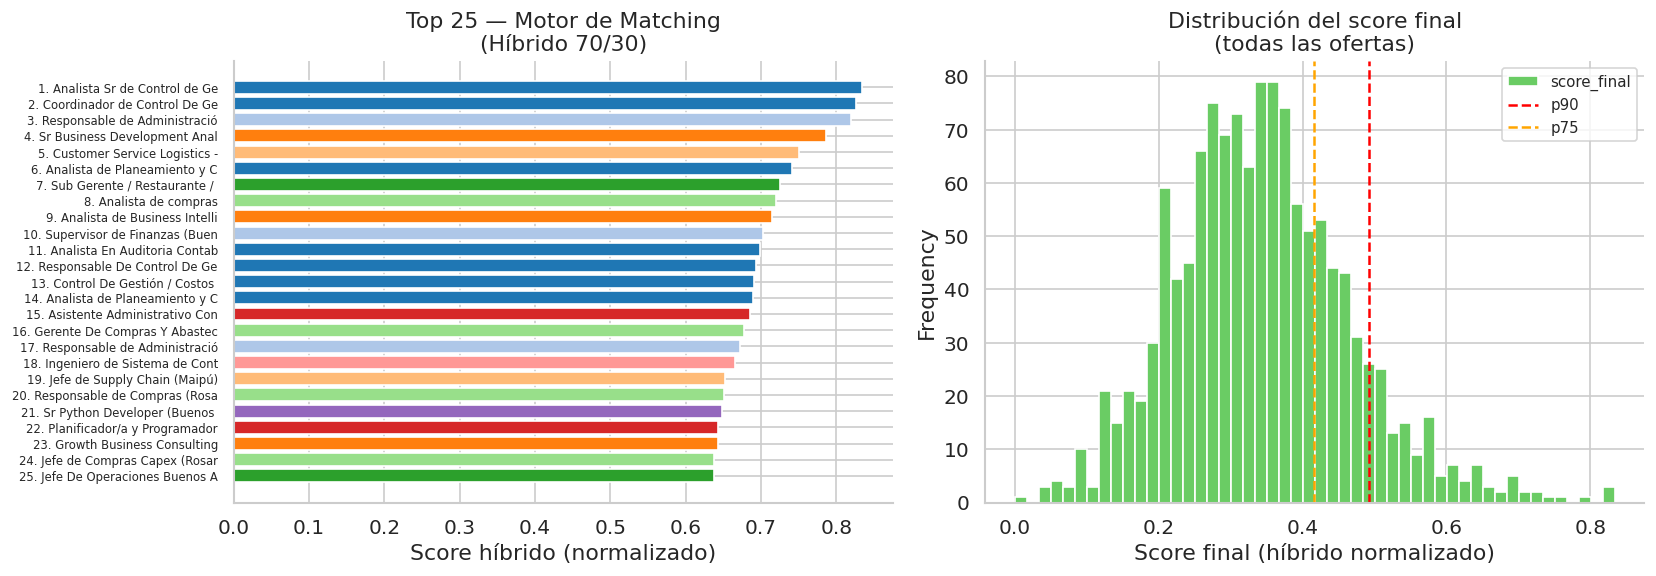

In [8]:
# ── Visualización del ranking final ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 25 — score final
top25 = df_ranking.head(25)
kws_u = top25['keyword'].unique()
kw_col = {kw: c for kw, c in zip(kws_u, sns.color_palette('tab20', len(kws_u)))}
colores = [kw_col.get(kw, 'gray') for kw in top25['keyword']]
axes[0].barh(range(25, 0, -1), top25['score_final'], color=colores)
axes[0].set_yticks(range(1, 26))
axes[0].set_yticklabels(
    [f'{r}. {t[:28]}' for r, t in
     zip(range(25, 0, -1), top25['titulo'].str[:28].values[::-1])],
    fontsize=7)
axes[0].set_xlabel('Score híbrido (normalizado)')
axes[0].set_title(f'Top 25 — Motor de Matching\n({CONFIG_PRINCIPAL})')

# Distribución del score final
df_motor['score_final'].plot(
    kind='hist', bins=50, ax=axes[1],
    color=sns.color_palette('muted')[2], edgecolor='white')
axes[1].axvline(df_motor['score_final'].quantile(0.90),
                color='red', ls='--', lw=1.5, label='p90')
axes[1].axvline(df_motor['score_final'].quantile(0.75),
                color='orange', ls='--', lw=1.5, label='p75')
axes[1].set_xlabel('Score final (híbrido normalizado)')
axes[1].set_title('Distribución del score final\n(todas las ofertas)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(_FIGS / 'fig_t6_01_ranking_final.png', dpi=150, bbox_inches='tight')
plt.show()


=== Correlación de Spearman entre configuraciones ===
(1.0 = rankings idénticos, 0.0 = sin relación)

               Solo SBERT  Híbrido 70/30  Híbrido 50/50  Solo TF-IDF
Solo SBERT         1.0000         0.8505         0.6414       0.1910
Híbrido 70/30      0.8505         1.0000         0.9422       0.6425
Híbrido 50/50      0.6414         0.9422         1.0000       0.8508
Solo TF-IDF        0.1910         0.6425         0.8508       1.0000



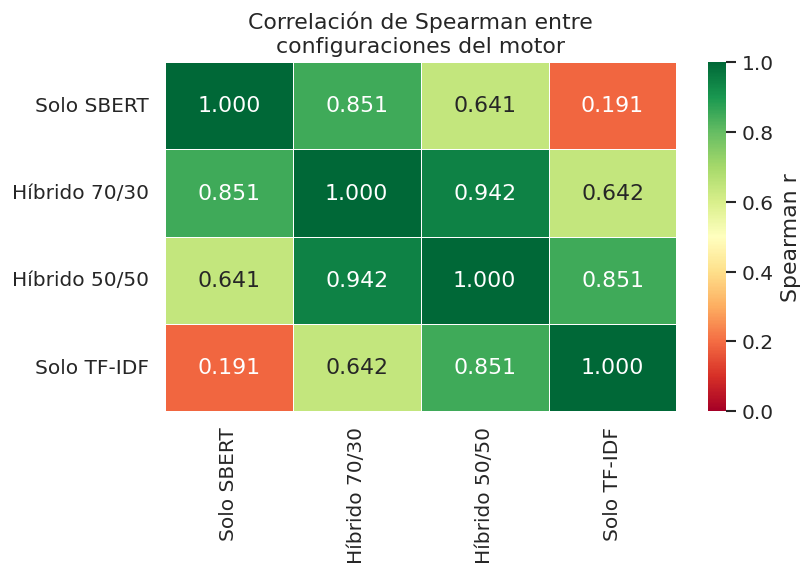

→ Correlación SBERT vs TF-IDF indica cuánto aporta cada modelo.
  Valor bajo = los modelos son complementarios (hibrido tiene sentido).


In [9]:
# ── Estabilidad del ranking: correlación entre configuraciones ────────────────
if tiene_embed and tiene_tfidf:
    print('=== Correlación de Spearman entre configuraciones ===')
    print('(1.0 = rankings idénticos, 0.0 = sin relación)')
    print()

    configs = list(CONFIGS.keys())
    scores_cols = [f'score_{c}' for c in configs if f'score_{c}' in df_motor.columns]

    corr_matrix = pd.DataFrame(index=configs, columns=configs, dtype=float)
    for c1 in configs:
        for c2 in configs:
            col1, col2 = f'score_{c1}', f'score_{c2}'
            if col1 in df_motor.columns and col2 in df_motor.columns:
                r, _ = spearmanr(df_motor[col1].fillna(0), df_motor[col2].fillna(0))
                corr_matrix.loc[c1, c2] = round(r, 4)

    print(corr_matrix.to_string())
    print()

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(corr_matrix.astype(float), annot=True, fmt='.3f',
                cmap='RdYlGn', vmin=0, vmax=1, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Spearman r'})
    ax.set_title('Correlación de Spearman entre\nconfiguraciones del motor')
    plt.tight_layout()
    plt.savefig(_FIGS / 'fig_t6_02_correlacion_configs.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('→ Correlación SBERT vs TF-IDF indica cuánto aporta cada modelo.')
    print('  Valor bajo = los modelos son complementarios (hibrido tiene sentido).')
else:
    print('ℹ️  Solo un modelo disponible — análisis de estabilidad omitido.')


## 4. Métricas de evaluación del ranking

### Contexto: evaluación sin ground truth

En un sistema de recomendación laboral real, la relevancia de una oferta  
para un candidato requiere juicio humano (¿postularía? ¿es adecuada?).  
Sin ese juicio experto, usamos **dos proxies complementarios**:

**Proxy 1 — Relevancia binaria por umbral de similitud:**  
Una oferta es *relevante* si su score supera un umbral $\theta$.  
Permite calcular **Precision@K**: de las K primeras recomendadas, ¿cuántas son relevantes?

**Proxy 2 — Relevancia graduada (similitud continua):**  
El score de similitud es la relevancia. Permite calcular **nDCG@K** y **MRR**.

### Métricas implementadas

| Métrica | Descripción | Interpretación |
|---|---|---|
| **Precision@K** | Proporción de items relevantes en el Top-K | % de recomendaciones útiles |
| **nDCG@K** | Normalized Discounted Cumulative Gain | Calidad del ordenamiento (penaliza posiciones bajas) |
| **MRR** | Mean Reciprocal Rank | Posición del primer item relevante |


In [10]:
# ── Implementación de métricas ────────────────────────────────────────────────

def precision_at_k(scores_ordenados: np.ndarray, k: int, theta: float) -> float:
    """Proporción de items relevantes (score >= theta) en el Top-K."""
    top_k = scores_ordenados[:k]
    return (top_k >= theta).sum() / k

def dcg_at_k(scores_ordenados: np.ndarray, k: int) -> float:
    """Discounted Cumulative Gain: suma ponderada por posición."""
    gains = scores_ordenados[:k]
    discounts = np.log2(np.arange(2, k + 2))  # log2(2), log2(3), ...
    return (gains / discounts).sum()

def ndcg_at_k(scores_ordenados: np.ndarray, k: int) -> float:
    """nDCG: DCG normalizado por el DCG ideal (scores perfectamente ordenados)."""
    ideal = np.sort(scores_ordenados)[::-1]  # mejor orden posible
    idcg  = dcg_at_k(ideal, k)
    if idcg == 0:
        return 0.0
    return dcg_at_k(scores_ordenados, k) / idcg

def mrr(scores_ordenados: np.ndarray, theta: float) -> float:
    """Mean Reciprocal Rank: reciproco de la posición del primer item relevante."""
    for i, s in enumerate(scores_ordenados, 1):
        if s >= theta:
            return 1.0 / i
    return 0.0

print('✅ Funciones de métricas definidas')
print('   precision_at_k | ndcg_at_k | mrr')


✅ Funciones de métricas definidas
   precision_at_k | ndcg_at_k | mrr


In [11]:
# ── Calcular métricas para cada configuración ─────────────────────────────────
# Umbral de relevancia: percentil 75 del score final
# (el 25% de las ofertas más similares se consideran 'relevantes')
THETA = df_motor['score_final'].quantile(0.75)
Ks    = [5, 10, 20, 50]

print(f'Umbral de relevancia θ = {THETA:.4f} (percentil 75 del score final)')
print(f'Ofertas relevantes según umbral: {(df_motor["score_final"] >= THETA).sum():,}')
print()

resultados_metricas = {}

for nombre, (w_emb, w_tfi) in CONFIGS.items():
    col = f'score_{nombre}'
    if col not in df_motor.columns:
        continue

    # Ordenar de mayor a menor score
    scores_ord = df_motor[col].fillna(0).sort_values(ascending=False).values

    metricas_config = {}
    for k in Ks:
        metricas_config[f'P@{k}']    = precision_at_k(scores_ord, k, THETA)
        metricas_config[f'nDCG@{k}'] = ndcg_at_k(scores_ord, k)
    metricas_config['MRR'] = mrr(scores_ord, THETA)

    resultados_metricas[nombre] = metricas_config

df_metricas = pd.DataFrame(resultados_metricas).T.round(4)
print('=== Métricas de evaluación por configuración ===')
print(df_metricas.to_string())


Umbral de relevancia θ = 0.4161 (percentil 75 del score final)
Ofertas relevantes según umbral: 320

=== Métricas de evaluación por configuración ===
               P@5  nDCG@5  P@10  nDCG@10  P@20  nDCG@20  P@50  nDCG@50  MRR
Solo SBERT     1.0     1.0   1.0      1.0   1.0      1.0   1.0      1.0  1.0
Híbrido 70/30  1.0     1.0   1.0      1.0   1.0      1.0   1.0      1.0  1.0
Híbrido 50/50  1.0     1.0   1.0      1.0   1.0      1.0   1.0      1.0  1.0
Solo TF-IDF    1.0     1.0   1.0      1.0   1.0      1.0   1.0      1.0  1.0


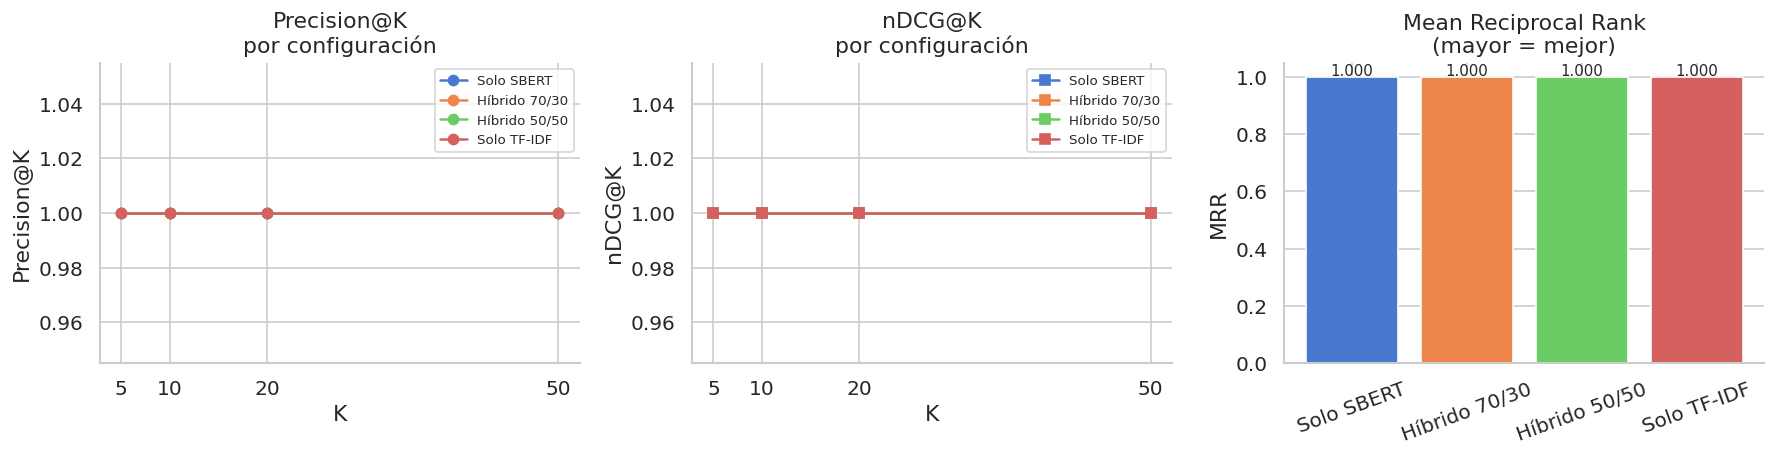

In [12]:
# ── Visualización de métricas ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colores_config = sns.color_palette('muted', len(CONFIGS))
configs_disp   = [c for c in CONFIGS if c in df_metricas.index]

# Precision@K
p_cols = [f'P@{k}' for k in Ks if f'P@{k}' in df_metricas.columns]
for i, config in enumerate(configs_disp):
    vals = [df_metricas.loc[config, c] for c in p_cols]
    axes[0].plot(Ks[:len(p_cols)], vals, marker='o', label=config,
                 color=colores_config[i])
axes[0].set_xlabel('K')
axes[0].set_ylabel('Precision@K')
axes[0].set_title('Precision@K\npor configuración')
axes[0].legend(fontsize=8)
axes[0].set_xticks(Ks)

# nDCG@K
n_cols = [f'nDCG@{k}' for k in Ks if f'nDCG@{k}' in df_metricas.columns]
for i, config in enumerate(configs_disp):
    vals = [df_metricas.loc[config, c] for c in n_cols]
    axes[1].plot(Ks[:len(n_cols)], vals, marker='s', label=config,
                 color=colores_config[i])
axes[1].set_xlabel('K')
axes[1].set_ylabel('nDCG@K')
axes[1].set_title('nDCG@K\npor configuración')
axes[1].legend(fontsize=8)
axes[1].set_xticks(Ks)

# MRR
if 'MRR' in df_metricas.columns:
    mrr_vals = [df_metricas.loc[c, 'MRR'] for c in configs_disp]
    bars = axes[2].bar(configs_disp, mrr_vals,
                       color=colores_config[:len(configs_disp)])
    for bar, val in zip(bars, mrr_vals):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', fontsize=9)
    axes[2].set_ylabel('MRR')
    axes[2].set_title('Mean Reciprocal Rank\n(mayor = mejor)')
    axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(_FIGS / 'fig_t6_03_metricas.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Análisis de calidad del matching por dimensión

In [13]:
# ── Score por keyword ─────────────────────────────────────────────────────────
score_kw = (df_ranking.groupby('keyword')['score_final']
            .agg(['mean','max','count'])
            .sort_values('mean', ascending=False)
            .round(4))
score_kw.columns = ['Score promedio', 'Score máximo', 'N ofertas']

print('=== Score del motor por keyword ===')
print(score_kw.to_string())


=== Score del motor por keyword ===
                        Score promedio  Score máximo  N ofertas
keyword                                                        
Compras / Procurement           0.3925        0.7194        142
Gerente de Operaciones          0.3924        0.7249         88
Finanzas / CAPEX                0.3805        0.8197         77
Control de Gestión              0.3566        0.8337        154
Ingeniero Industrial            0.3562        0.6659        111
Supply Chain                    0.3514        0.7505        110
Python Developer                0.3334        0.6478         89
BI / Analytics                  0.3266        0.7864        122
Excel / VBA                     0.3196        0.6856        129
Data Scientist                  0.2977        0.5770        159
Continuous Improvement          0.2801        0.4561         98


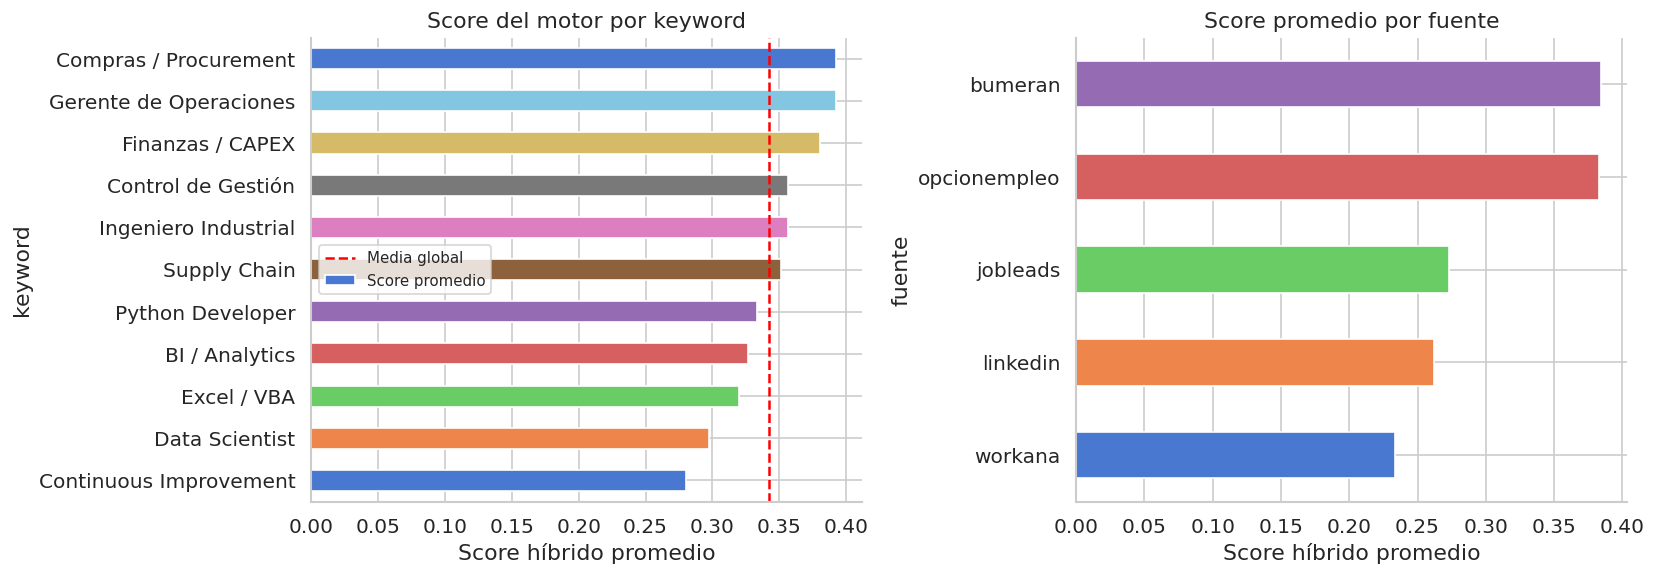

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score promedio por keyword
score_kw['Score promedio'].sort_values().plot(
    kind='barh', ax=axes[0],
    color=sns.color_palette('muted', len(score_kw)))
axes[0].axvline(df_ranking['score_final'].mean(),
                color='red', ls='--', lw=1.5, label='Media global')
axes[0].set_xlabel('Score híbrido promedio')
axes[0].set_title('Score del motor por keyword')
axes[0].legend(fontsize=9)

# Distribución por fuente
score_fuente = (df_ranking.groupby('fuente')['score_final']
                .agg(['mean','count'])
                .sort_values('mean', ascending=True))
score_fuente['mean'].plot(
    kind='barh', ax=axes[1],
    color=sns.color_palette('muted', len(score_fuente)))
axes[1].set_xlabel('Score híbrido promedio')
axes[1].set_title('Score promedio por fuente')

plt.tight_layout()
plt.savefig(_FIGS / 'fig_t6_04_score_por_dimension.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# ── Score por modalidad ───────────────────────────────────────────────────────
if 'modalidad' in df_ranking.columns:
    score_mod = (df_ranking.groupby('modalidad')['score_final']
                 .agg(['mean','count'])
                 .sort_values('mean', ascending=False)
                 .round(4))
    score_mod.columns = ['Score promedio', 'N ofertas']
    print('=== Score por modalidad ===')
    print(score_mod.to_string())
    print()
    print('→ Si "Remoto" tiene score más alto, el perfil del CV tiene mayor afinidad')
    print('  con ofertas remotas que con presenciales en la región.')


=== Score por modalidad ===
            Score promedio  N ofertas
modalidad                            
Híbrido             0.3887         25
Presencial          0.3842         69
Remoto              0.2421         40

→ Si "Remoto" tiene score más alto, el perfil del CV tiene mayor afinidad
  con ofertas remotas que con presenciales en la región.


## 6. Casos de estudio cualitativos

El análisis cualitativo del Top-10 permite validar que el motor está  
recomendando ofertas semánticamente coherentes con el perfil del CV,  
más allá de lo que muestran las métricas numéricas.


In [16]:
# ── Top 10 con descripción parcial ───────────────────────────────────────────
print('=' * 70)
print('  TOP 10 — Motor de Matching (análisis cualitativo)')
print('=' * 70)

for _, row in df_ranking.head(10).iterrows():
    rank  = row['rank_final']
    score = row['score_final']
    titulo  = str(row.get('titulo', 'N/A'))[:55]
    empresa = str(row.get('empresa', 'N/A'))[:35]
    keyword = str(row.get('keyword', ''))[:30]
    fuente  = str(row.get('fuente', ''))[:15]
    modalidad = str(row.get('modalidad', 'N/A'))[:20]
    url     = str(row.get('url', ''))[:70]

    # Similitudes individuales
    s_emb  = f"{row['similitud_embed']:.4f}" if 'similitud_embed' in row and pd.notna(row.get('similitud_embed')) else 'N/A'
    s_tfi  = f"{row['similitud_tfidf']:.4f}" if 'similitud_tfidf' in row and pd.notna(row.get('similitud_tfidf')) else 'N/A'

    # Snippet de descripción
    desc = str(row.get('descripcion', '') or '')[:200].replace(chr(10), ' ')

    print(f'#{rank:>2}. {titulo}')
    print(f'    Empresa   : {empresa}')
    print(f'    Keyword   : {keyword}  |  Fuente: {fuente}  |  Modalidad: {modalidad}')
    print(f'    Score     : {score:.4f}  (SBERT={s_emb}, TF-IDF={s_tfi})')
    print(f'    URL       : {url}')
    if desc:
        print(f'    Descripción: {desc}...')
    print()


  TOP 10 — Motor de Matching (análisis cualitativo)
# 1. Analista Sr de Control de Gestión (Buenos Aires)
    Empresa   : Vanguardia Consultores RR.HH
    Keyword   : Control de Gestión  |  Fuente: opcionempleo  |  Modalidad: nan
    Score     : 0.8337  (SBERT=0.5894, TF-IDF=0.1067)
    URL       : https://www.opcionempleo.com.ar/jobad/ar2edc5387bfc7b6f0054cdeac752be9
    Descripción: Estamos buscando un/a Analista Senior de Control de Gestión – La Plata (Híbrido) Queremos sumar a alguien que ame los datos, los procesos y la mejora continua. Si 할 te motiva transformar información e...

# 2. Coordinador de Control De Gestion (Buenos Aires)
    Empresa   : Newsan
    Keyword   : Control de Gestión  |  Fuente: opcionempleo  |  Modalidad: nan
    Score     : 0.8258  (SBERT=0.5933, TF-IDF=0.0990)
    URL       : https://www.opcionempleo.com.ar/jobad/areccf663a96b2635801cd0a7022c97e
    Descripción: Coordinador de Control De Gestión Desde la Unidad de Negocios de Electrónica de consumo y ele

In [17]:
# ── Análisis de variación de ranking entre modelos ────────────────────────────
if 'rank_tfidf' in df_ranking.columns and 'rank_embed' in df_ranking.columns:
    top50 = df_ranking.head(50).copy()
    top50['delta_rank'] = top50['rank_tfidf'] - top50['rank_embed']

    print('Ofertas donde SBERT y TF-IDF discrepan más (Top 50 final):')
    print('delta > 0 → SBERT lo rankea más arriba que TF-IDF')
    print()

    discrepancias = (top50[['rank_final','rank_embed','rank_tfidf',
                             'delta_rank','score_final','titulo','keyword']]
                     .sort_values('delta_rank', ascending=False)
                     .head(10))
    print(discrepancias.to_string(index=False))
    print()
    print('→ Estas son las ofertas que el motor híbrido valora por encima')
    print('  del baseline TF-IDF gracias a la comprensión semántica de SBERT.')


Ofertas donde SBERT y TF-IDF discrepan más (Top 50 final):
delta > 0 → SBERT lo rankea más arriba que TF-IDF

 rank_final  rank_embed  rank_tfidf  delta_rank  score_final                                                                                    titulo                keyword
         23           7         983         976     0.642772                                                                Growth Business Consulting         BI / Analytics
         17           5         811         806     0.671727                   Responsable de Administración y Finanzas - AgroGanadería (Buenos Aires)       Finanzas / CAPEX
         15           6         696         690     0.685577               Asistente Administrativo Contable – Carrera y Excel Avanzado (Buenos Aires)            Excel / VBA
         30          15         695         680     0.624559                             Desarrollador Semi Senior Python / Laravel / Php Buenos Aires       Python Developer
         38         

## 7. Persistencia de artefactos

In [18]:
# ── Ranking final combinado ───────────────────────────────────────────────────
COLS_RANKING_OUT = ['rank_final', 'id_consolidado', 'fuente', 'titulo', 'empresa',
                    'keyword', 'ubicacion', 'modalidad', 'url',
                    'score_final', 'similitud_embed', 'similitud_tfidf',
                    'rank_embed', 'rank_tfidf']
cols_out = [c for c in COLS_RANKING_OUT if c in df_ranking.columns]
df_ranking[cols_out].to_csv(_RANKINGS / 'ranking_final_combinado.csv', index=False, encoding='utf-8')
print(f'✅ ranking_final_combinado.csv — {len(df_ranking):,} filas')


✅ ranking_final_combinado.csv — 1,279 filas


In [19]:
# ── Métricas de evaluación ────────────────────────────────────────────────────
metricas_out = {
    'fecha_evaluacion':  datetime.now().isoformat(),
    'n_documentos':      len(df_motor),
    'umbral_relevancia': round(float(THETA), 4),
    'config_principal':  CONFIG_PRINCIPAL,
    'modelo_embed':      modelo_info.get('modelo', 'N/A'),
    'configuraciones':   {
        k: {m: round(float(v), 4) for m, v in vals.items()}
        for k, vals in resultados_metricas.items()
    }
}
(_REPORTS / 'metricas_evaluacion.json').write_text(
    json.dumps(metricas_out, ensure_ascii=False, indent=2), encoding='utf-8')
print('✅ metricas_evaluacion.json')
print(json.dumps(metricas_out, indent=2, ensure_ascii=False))


✅ metricas_evaluacion.json
{
  "fecha_evaluacion": "2026-04-23T23:33:07.297882",
  "n_documentos": 1279,
  "umbral_relevancia": 0.4161,
  "config_principal": "Híbrido 70/30",
  "modelo_embed": "paraphrase-multilingual-MiniLM-L12-v2",
  "configuraciones": {
    "Solo SBERT": {
      "P@5": 1.0,
      "nDCG@5": 1.0,
      "P@10": 1.0,
      "nDCG@10": 1.0,
      "P@20": 1.0,
      "nDCG@20": 1.0,
      "P@50": 1.0,
      "nDCG@50": 1.0,
      "MRR": 1.0
    },
    "Híbrido 70/30": {
      "P@5": 1.0,
      "nDCG@5": 1.0,
      "P@10": 1.0,
      "nDCG@10": 1.0,
      "P@20": 1.0,
      "nDCG@20": 1.0,
      "P@50": 1.0,
      "nDCG@50": 1.0,
      "MRR": 1.0
    },
    "Híbrido 50/50": {
      "P@5": 1.0,
      "nDCG@5": 1.0,
      "P@10": 1.0,
      "nDCG@10": 1.0,
      "P@20": 1.0,
      "nDCG@20": 1.0,
      "P@50": 1.0,
      "nDCG@50": 1.0,
      "MRR": 1.0
    },
    "Solo TF-IDF": {
      "P@5": 1.0,
      "nDCG@5": 1.0,
      "P@10": 1.0,
      "nDCG@10": 1.0,
      "P@20": 1.0,

In [20]:
# ── Reporte en Markdown para la tesis ────────────────────────────────────────
lineas = [
    '# Reporte del Motor de Matching — T6',
    '',
    f'**Fecha:** {datetime.now().strftime("%Y-%m-%d %H:%M")}  ',
    f'**Configuración activa:** {CONFIG_PRINCIPAL}  ',
    f'**Modelo de embeddings:** {modelo_info.get("modelo", "N/A")}  ',
    f'**Corpus:** {len(df_motor):,} ofertas  ',
    '',
    '## Métricas de evaluación',
    '',
    '| Configuración | P@5 | P@10 | nDCG@10 | nDCG@20 | MRR |',
    '|---|---|---|---|---|---|',
]
for cfg in configs_disp:
    if cfg in resultados_metricas:
        m = resultados_metricas[cfg]
        lineas.append(
            f'| {cfg} '
            f'| {m.get("P@5",0):.3f} '
            f'| {m.get("P@10",0):.3f} '
            f'| {m.get("nDCG@10",0):.3f} '
            f'| {m.get("nDCG@20",0):.3f} '
            f'| {m.get("MRR",0):.3f} |'
        )

lineas += ['', '## Top 20 ofertas recomendadas', '']
lineas.append('| Rank | Score | Título | Empresa | Keyword | Fuente | Modalidad |')
lineas.append('|---|---|---|---|---|---|---|')
for _, row in df_ranking.head(20).iterrows():
    lineas.append(
        f'| {int(row["rank_final"])} '
        f'| {row["score_final"]:.4f} '
        f'| {str(row.get("titulo",""))[:45]} '
        f'| {str(row.get("empresa",""))[:30]} '
        f'| {str(row.get("keyword",""))[:25]} '
        f'| {str(row.get("fuente",""))} '
        f'| {str(row.get("modalidad",""))} |'
    )

(_REPORTS / 'reporte_matching.md').write_text(chr(10).join(lineas), encoding='utf-8')
print('✅ reporte_matching.md')

print()
print('Archivos generados:')
rutas_salida = {
    'ranking_final_combinado.csv': _RANKINGS / 'ranking_final_combinado.csv',
    'metricas_evaluacion.json'   : _REPORTS  / 'metricas_evaluacion.json',
    'reporte_matching.md'        : _REPORTS  / 'reporte_matching.md',
}
for fn, p in rutas_salida.items():
    if p.exists():
        print(f'  📄 {fn:<40} {p.stat().st_size/1024:.0f} KB')


✅ reporte_matching.md

Archivos generados:
  📄 ranking_final_combinado.csv              333 KB
  📄 metricas_evaluacion.json                 1 KB
  📄 reporte_matching.md                      3 KB


## 8. Resumen ejecutivo de T6

In [21]:
print('=' * 65)
print('  RESUMEN — T6: Motor de Similitud y Cálculo de Ranks')
print('=' * 65)
print(f"  Fecha : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print()
print('  MOTOR')
print(f'    Configuración activa : {CONFIG_PRINCIPAL}')
print(f'    Modelos integrados   : {"TF-IDF + SBERT" if tiene_tfidf and tiene_embed else "SBERT" if tiene_embed else "TF-IDF"}')
print(f'    Ofertas rankeadas    : {len(df_ranking):,}')
print()
print('  MÉTRICAS (configuración principal)')
if CONFIG_PRINCIPAL in resultados_metricas:
    m = resultados_metricas[CONFIG_PRINCIPAL]
    print(f'    Precision@5  : {m.get("P@5",0):.4f}')
    print(f'    Precision@10 : {m.get("P@10",0):.4f}')
    print(f'    nDCG@10      : {m.get("nDCG@10",0):.4f}')
    print(f'    nDCG@20      : {m.get("nDCG@20",0):.4f}')
    print(f'    MRR          : {m.get("MRR",0):.4f}')
print()
print('  TOP 5 del ranking final:')
for _, row in df_ranking.head(5).iterrows():
    print(f'    #{int(row["rank_final"]):>2}. [{row["score_final"]:.4f}] {str(row["titulo"])[:45]}')
print()
print('  ARTEFACTOS GENERADOS (input para T7)')
print('    📄 ranking_final_combinado.csv')
print('    📄 metricas_evaluacion.json')
print('    📄 reporte_matching.md')
print()
print('  PRÓXIMO PASO: T7 — Evaluación con Benchmark')
print('=' * 65)


  RESUMEN — T6: Motor de Similitud y Cálculo de Ranks
  Fecha : 2026-04-23 23:33

  MOTOR
    Configuración activa : Híbrido 70/30
    Modelos integrados   : TF-IDF + SBERT
    Ofertas rankeadas    : 1,279

  MÉTRICAS (configuración principal)
    Precision@5  : 1.0000
    Precision@10 : 1.0000
    nDCG@10      : 1.0000
    nDCG@20      : 1.0000
    MRR          : 1.0000

  TOP 5 del ranking final:
    # 1. [0.8337] Analista Sr de Control de Gestión (Buenos Air
    # 2. [0.8258] Coordinador de Control De Gestion (Buenos Air
    # 3. [0.8197] Responsable de Administración y Finanzas - Ru
    # 4. [0.7864] Sr Business Development Analyst (Buenos Aires
    # 5. [0.7505] Customer Service Logistics - Supply Chain (Vi

  ARTEFACTOS GENERADOS (input para T7)
    📄 ranking_final_combinado.csv
    📄 metricas_evaluacion.json
    📄 reporte_matching.md

  PRÓXIMO PASO: T7 — Evaluación con Benchmark
